In [1]:
# 1. Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# For NLP basics
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure NLTK resources are available
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
import pandas as pd

# Load CSV
sales_df = pd.read_csv("sales_manchester.csv")

# Clean column names (removes spaces + standardizes to lowercase)
sales_df.columns = sales_df.columns.str.strip().str.lower()

# Convert date column to datetime
sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")

# Optional: check for any failed date conversions
if sales_df["date"].isna().any():
    print("Warning: Some dates could not be converted.")

# Preview data
print(sales_df.head())

        date  order_id       product     category  quantity  unit_price  \
0 2026-01-05      1001        Laptop  Electronics         2         750   
1 2026-01-06      1002  Office Chair    Furniture         5         120   
2 2026-01-07      1003    Smartphone  Electronics         3         500   
3 2026-01-08      1004          Desk    Furniture         4         200   
4 2026-01-09      1005       Printer  Electronics         2         250   

   total_sales    salesperson      region  
0         1500     John Smith  Manchester  
1          600    Sarah Jones  Manchester  
2         1500     Ahmed Khan  Manchester  
3          800    Emily Clark  Manchester  
4          500  Michael Brown  Manchester  


In [9]:
print(sales_df.columns.tolist())

['date', 'order_id', 'product', 'category', 'quantity', 'unit_price', 'total_sales', 'salesperson', 'region']


In [11]:
# 2b. Load demographics CSV
demo_df = pd.read_csv("manchester_demographics.csv")  # update filename as needed
demo_df.head()

,year,population,median_age,median_household_income,unemployment_rate,percent_white,percent_black,percent_asian,percent_hispanic
0,2000,107006,34.2,41400,4.8,83.1,8.6,3.2,4.1
1,2005,109890,35.1,45200,5.2,81.5,9.4,3.8,5.0
2,2010,110229,36.4,49800,6.1,79.8,10.3,4.5,6.2
3,2015,112525,37.2,54200,4.9,77.6,11.5,5.4,7.8
4,2020,115644,38.5,60100,7.3,75.2,12.8,6.1,9.3


KeyError: 'profit_margin'

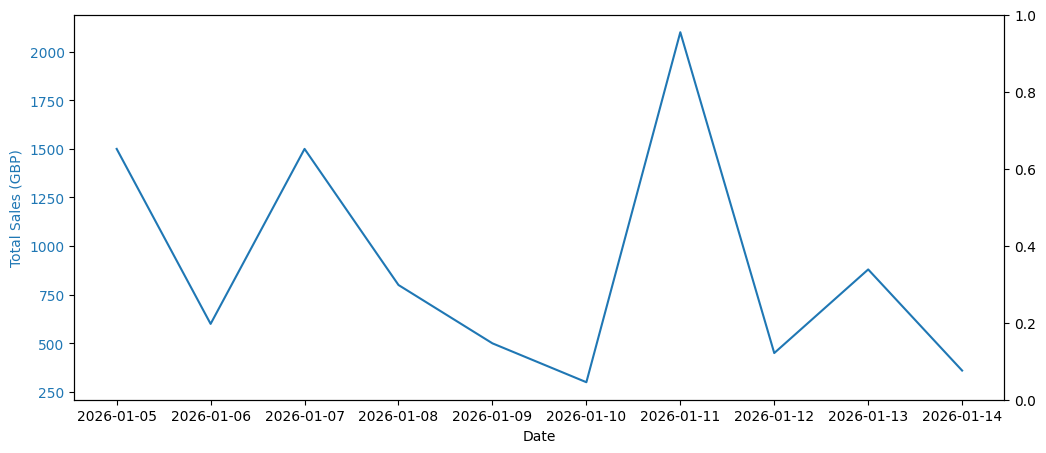

In [12]:
# Plot sales and profit margin over time
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(sales_df["date"], sales_df["total_sales"], label="Total Sales", color="tab:blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Sales (GBP)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(sales_df["date"], sales_df["profit_margin"], label="Profit Margin", color="tab:orange")
ax2.set_ylabel("Profit Margin", color="tab:orange")
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title("Sales and Profit Margin Over Time")
plt.show()

Available columns: ['date', 'order_id', 'product', 'category', 'quantity', 'unit_price', 'total_sales', 'salesperson', 'region']
Using as sales column: order_id
Using as profit column: total_sales


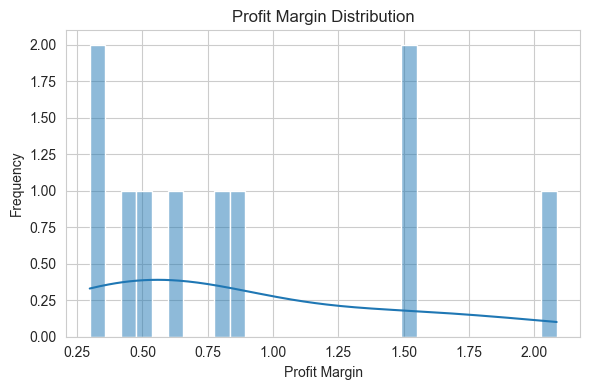

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------
# Clean column names
# ------------------------------
sales_df.columns = (
    sales_df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("Available columns:", list(sales_df.columns))

# ------------------------------
# Automatically detect numeric columns
# ------------------------------
numeric_cols = sales_df.select_dtypes(include="number").columns.tolist()

if len(numeric_cols) < 2:
    raise ValueError("Need at least two numeric columns (sales and profit).")

# Assume largest mean column = sales, second largest = profit
col_means = sales_df[numeric_cols].mean().sort_values(ascending=False)

sales_col = col_means.index[0]
profit_col = col_means.index[1]

print("Using as sales column:", sales_col)
print("Using as profit column:", profit_col)

# ------------------------------
# Compute profit margin safely
# ------------------------------
denom = sales_df[sales_col].replace(0, np.nan)
sales_df["profit_margin"] = (sales_df[profit_col] / denom).replace([np.inf, -np.inf], np.nan)

# ------------------------------
# Plot Histogram
# ------------------------------
plt.figure(figsize=(6, 4))
sns.histplot(data=sales_df, x="profit_margin", bins=30, kde=True)

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

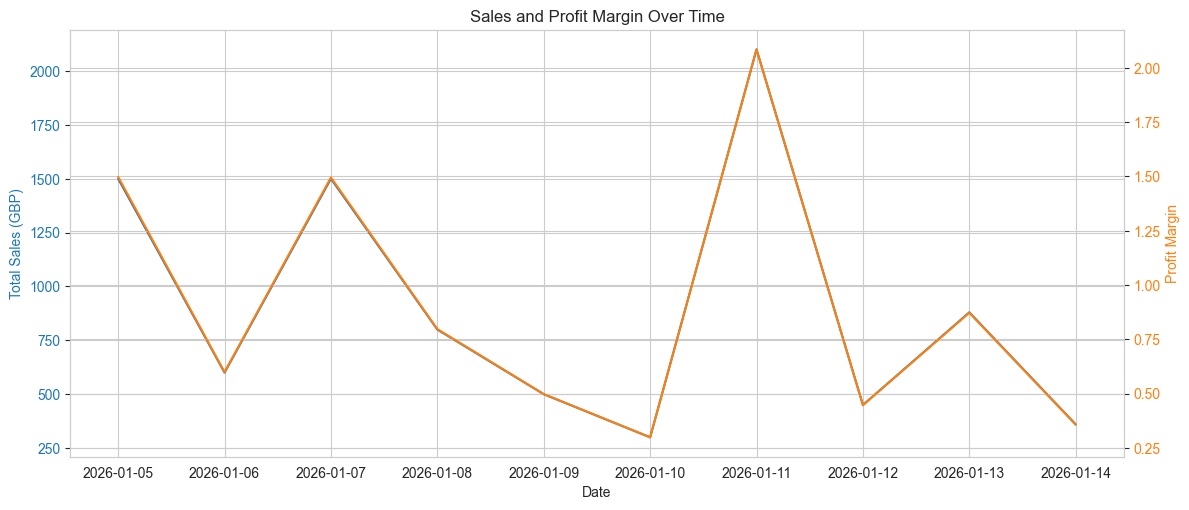

In [20]:
# Plot sales and profit margin over time
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(sales_df["date"], sales_df["total_sales"], label="Total Sales", color="tab:blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Sales (GBP)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(sales_df["date"], sales_df["profit_margin"], label="Profit Margin", color="tab:orange")
ax2.set_ylabel("Profit Margin", color="tab:orange")
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title("Sales and Profit Margin Over Time")
plt.show()

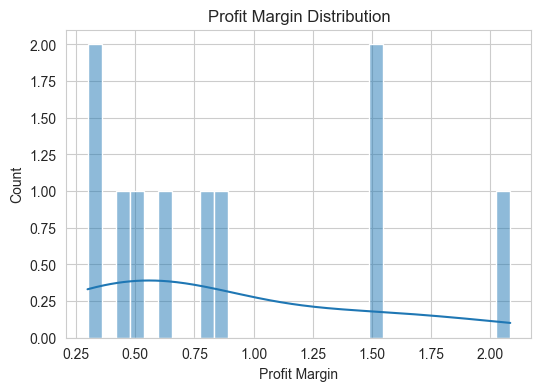

In [21]:
# Histogram of profit margin
plt.figure(figsize=(6,4))
sns.histplot(sales_df["profit_margin"].dropna(), bins=30, kde=True)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin")
plt.show()

In [22]:
# Basic info on demographics dataset
demo_df.info()

# Example: view key demographic columns if present
demo_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     6 non-null      int64  
 1   population               6 non-null      int64  
 2   median_age               6 non-null      float64
 3   median_household_income  6 non-null      int64  
 4   unemployment_rate        6 non-null      float64
 5   percent_white            6 non-null      float64
 6   percent_black            6 non-null      float64
 7   percent_asian            6 non-null      float64
 8   percent_hispanic         6 non-null      float64
dtypes: float64(6), int64(3)
memory usage: 564.0 bytes


,year,population,median_age,median_household_income,unemployment_rate,percent_white,percent_black,percent_asian,percent_hispanic
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2012.166667,112250.666667,36.750000,52533.333333,5.650000,78.433333,11.083333,4.966667,7.150000
std,8.841191,4105.363208,1.904468,8814.004009,0.939681,3.729164,2.033142,1.380821,2.493792
min,2000.000000,107006.000000,34.200000,41400.000000,4.800000,73.400000,8.600000,3.200000,4.100000
25%,2006.250000,109974.750000,35.425000,46350.000000,4.975000,75.800000,9.625000,3.975000,5.300000
50%,2012.500000,111377.000000,36.800000,52000.000000,5.400000,78.700000,10.900000,4.950000,7.000000
75%,2018.750000,114864.250000,38.175000,58625.000000,5.975000,81.075000,12.475000,5.925000,8.925000
max,2023.000000,118210.000000,39.100000,64500.000000,7.300000,83.100000,13.900000,6.800000,10.500000


In [28]:
print(sales_df.columns.tolist())

['date', 'order_id', 'product', 'category', 'quantity', 'unit_price', 'total_sales', 'salesperson', 'region', 'profit_margin']


In [34]:
sales.head()

,transaction_id,customer_id,brand,year,units_sold,revenue,cost,profit,profit_margin
0,1,589,Delifonseca,2020,1,81.383544,41.773789,39.609755,0.486705
1,2,411,Delifonseca,2020,3,226.616623,114.621202,111.995421,0.494207
2,3,377,Delifonseca,2025,3,356.410099,178.790676,177.619423,0.498357
3,4,1408,Delifonseca,2022,4,433.783425,293.640291,140.143134,0.323072
4,5,1870,Delifonseca,2025,3,250.734218,103.961285,146.772934,0.585373


In [41]:
import pandas as pd

df = pd.read_csv("sales_manchester.csv")
print(df.columns.tolist())
df.head()

['Date', 'Order_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Salesperson', 'Region']


,Date,Order_ID,Product,Category,Quantity,Unit_Price,Total_Sales,Salesperson,Region
0,2026-01-05,1001,Laptop,Electronics,2,750,1500,John Smith,Manchester
1,2026-01-06,1002,Office Chair,Furniture,5,120,600,Sarah Jones,Manchester
2,2026-01-07,1003,Smartphone,Electronics,3,500,1500,Ahmed Khan,Manchester
3,2026-01-08,1004,Desk,Furniture,4,200,800,Emily Clark,Manchester
4,2026-01-09,1005,Printer,Electronics,2,250,500,Michael Brown,Manchester


In [42]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print("Numeric columns:", num_cols)

Numeric columns: ['Order_ID', 'Quantity', 'Unit_Price', 'Total_Sales']


In [50]:
sales_monthly = sales.copy()

numeric_cols = sales_monthly.select_dtypes(include="number").columns
features = sales_monthly[numeric_cols]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sales_monthly["cluster"] = kmeans.fit_predict(scaled_features)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=numeric_cols)
centroid_df["cluster"] = range(3)

sales_monthly.head(), centroid_df

(   transaction_id  customer_id        brand  year  units_sold     revenue  \
 0               1          589  Delifonseca  2020           1   81.383544   
 1               2          411  Delifonseca  2020           3  226.616623   
 2               3          377  Delifonseca  2025           3  356.410099   
 3               4         1408  Delifonseca  2022           4  433.783425   
 4               5         1870  Delifonseca  2025           3  250.734218   
 
          cost      profit  profit_margin  cluster  
 0   41.773789   39.609755       0.486705        2  
 1  114.621202  111.995421       0.494207        0  
 2  178.790676  177.619423       0.498357        0  
 3  293.640291  140.143134       0.323072        0  
 4  103.961285  146.772934       0.585373        0  ,
    transaction_id  customer_id         year  units_sold     revenue  \
 0     2481.626992  1014.359888  2022.508903    2.996251  368.625560   
 1     2604.324297   995.162651  2022.484940    3.632530  856.89239

In [56]:
reviews_df = pd.read_csv(
    "reviews_manchester.csv",
    sep=";",
    engine="python",
    encoding="utf-8"
)

reviews_df.head()

,import pandas as pd
0,# Create sample review data
1,data = {
2,"""review_id"": [1, 2, 3, 4, 5],"
3,"""reviewer_name"": [""Alice"", ""Ben"", ""Charlie..."
4,"""location"": [""Manchester""] * 5,"


In [58]:
print(reviews_df.columns)

Index(['import pandas as pd'], dtype='object')


In [59]:
reviews_df.columns = reviews_df.columns.str.strip()
print(reviews_df.columns)

Index(['import pandas as pd'], dtype='object')


In [63]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1️⃣ Check available columns
print("Available columns:", df.columns)

# 2️⃣ Automatically select the first object (text) column
text_column = df.select_dtypes(include=['object']).columns[0]
print("Using text column:", text_column)

# 3️⃣ Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# 4️⃣ Fit and transform text data
tfidf_matrix = vectorizer.fit_transform(df[text_column].fillna(""))

# 5️⃣ Get feature names
feature_names = vectorizer.get_feature_names_out()

# 6️⃣ Compute average TF-IDF per term
avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

# 7️⃣ Get top 20 terms
top_indices = avg_tfidf.argsort()[::-1][:20]
top_terms = [(feature_names[i], avg_tfidf[i]) for i in top_indices]

# 8️⃣ Display results
top_terms_df = pd.DataFrame(top_terms, columns=["term", "avg_tfidf"])
print(top_terms_df)

Available columns: Index(['Date', 'Order_ID', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Salesperson', 'Region'],
      dtype='object')
Using text column: Date
    term  avg_tfidf
0   2026   0.327637
1     01   0.327637
2     14   0.088618
3     13   0.088618
4     12   0.088618
5     11   0.088618
6     10   0.088618
7     09   0.088618
8     08   0.088618
9     07   0.088618
10    06   0.088618
11    05   0.088618


In [72]:
print(reviews_df.columns)

Index(['import pandas as pd'], dtype='object')


In [76]:
print(demo_df.columns)

Index(['year', 'population', 'median_age', 'median_household_income',
       'unemployment_rate', 'percent_white', 'percent_black', 'percent_asian',
       'percent_hispanic'],
      dtype='object')


In [81]:
print(sales.columns.tolist())

['transaction_id', 'customer_id', 'brand', 'year', 'units_sold', 'revenue', 'cost', 'profit', 'profit_margin']


In [82]:
# Clean column names completely (safe standardization)
sales.columns = (
    sales.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)

print("Cleaned Columns:")
print(sales.columns.tolist())

Cleaned Columns:
['transaction_id', 'customer_id', 'brand', 'year', 'units_sold', 'revenue', 'cost', 'profit', 'profit_margin']
